In [10]:
# --- IMPORTS ---
import pandas as pd              # Práca s tabuľkami (DataFrame)
import numpy as np               # Matematika a polia
import matplotlib.pyplot as plt  # Základné grafy
import seaborn as sns            # Krajšie štatistické grafy
import scipy.stats as stats      # Štatistické testy (T-testy, ANOVA...)
import statsmodels.api as sm     # Pokročilá štatistika (Regresia)
import statsmodels.formula.api as smf # R-style formuly pre regresiu

# Nastavenie dizajnu grafov
sns.set_theme(style="whitegrid", palette="muted")
%matplotlib inline

print("✅ Libraries successfully loaded!")

✅ Libraries successfully loaded!


# Linear regression
1. Load file

In [52]:
try:
    df = pd.read_excel('data_ku3.xls')
    print("✅ Data successfully loaded.")
except FileNotFoundError:
    print("ERROR: File not found.")

df['x'].count()

✅ Data successfully loaded.


18

## Plot values on graph

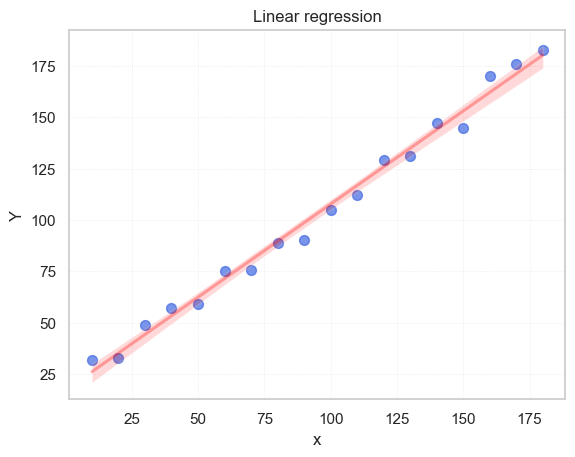

In [43]:
sns.set_theme(style="whitegrid")

# Scatter plot with regression line
graph = sns.regplot(data=df, x='x', y='Y',
           color='royalblue', 
           scatter_kws={'alpha': 0.7, 's': 50},
           line_kws={'color': 'red', 'alpha': 0.3})

graph.set_title("Linear regression")
graph.grid(True, alpha=0.2, linewidth=0.5, color='gray', linestyle=':')

plt.show()

Z grafu je zrejmé, že medzi závislou premennou ($Y$) a nezávislou premennou ($x$) existuje jasný **lineárny vzťah**. Regresná priamka má **stúpajúci trend**, čo indikuje **pozitívnu koreláciu**. Znamená to, že s narastajúcou hodnotou $x$ úmerne rastie aj hodnota $Y$."

In [48]:
# model = smf.ols(formula="Zavisla_Premenna ~ Nezávislá1 + Nezávislá2", data=df).fit() aka "Y ~ X1 + X2"
# formula automaticky predpokladá, že chceš v modeli priesečník s osou y aka sm.add_constant(X).
model = smf.ols('Q("Y") ~ Q("x")', data=df).fit()  # Ordinary least square = fith the best linear line
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                 Q("Y")   R-squared:                       0.989
Model:                            OLS   Adj. R-squared:                  0.989
Method:                 Least Squares   F-statistic:                     1505.
Date:                Mon, 09 Mar 2026   Prob (F-statistic):           2.96e-17
Time:                        20:53:17   Log-Likelihood:                -53.972
No. Observations:                  18   AIC:                             111.9
Df Residuals:                      16   BIC:                             113.7
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     17.0190      2.531      6.724      0.0

/Users/dagmarmac/miniforge3/lib/python3.12/site-packages/scipy/stats/_axis_nan_policy.py:430: UserWarning: `kurtosistest` p-value may be inaccurate with fewer than 20 observations; only n=18 observations were given.
  return hypotest_fun_in(*args, **kwds)


### 📊 Interpretácia výsledkov OLS Regresie

Z priloženej tabuľky vieme vyčítať kľúčové informácie o kvalite a vlastnostiach nášho modelu:

#### 1. Základné informácie o datasete a modeli
* **No. Observations (18):** Počet pozorovaní (riadkov v dátach), na ktorých bol model natrénovaný.
* **Df Model (1):** Stupne voľnosti modelu. Označuje počet **nezávislých premenných** (regresorov). Keďže používame iba jedno $x$, hodnota je 1.
* **Df Residuals (16):** Stupne voľnosti rezíduí (chýb). Počíta sa vzorcom $n - k - 1$ (počet pozorovaní mínus počet premenných mínus priesečník $\rightarrow 18 - 1 - 1 = 16$). 

#### 2. Kvalita modelu (Ako dobre predpovedáme?)
* **R-squared (0.989):** Koeficient determinácie. Náš model dokáže vysvetliť **98.9 % celkovej variability** závislej premennej $Y$. Body ležia takmer presne na regresnej priamke.
* **F-statistic (1505) a Prob(F-statistic) (2.96e-17):** Testujú model ako celok. Obrovská F-statistika a p-hodnota blízka nule (oveľa menšia ako 0.05) potvrdzujú, že nezávislá premenná $x$ **významne a preukázateľne ovplyvňuje** $Y$.

#### 3. Koeficienty a rovnica priamky
* **Intercept / Priesečník (17.0190):** Bod ($\beta_0$), kde regresná priamka pretína os Y. Ak by hodnota $x = 0$, náš model predpokladá, že hodnota $Y$ bude 17.0190.
* **Q("x") / Sklon (0.9071):** Koeficient ($\beta_1$) našej **nezávislej** premennej $x$. Hovorí nám o pozitívnej lineárnej závislosti: ak sa $x$ zvýši o 1 jednotku, hodnota $Y$ sa v priemere zvýši o 0.9071.
* **P>|t| (0.000):** Tzv. p-hodnoty pre jednotlivé koeficienty. Keďže sú skoro 0.000, máme istotu, že naše koeficienty sú skutočné a nevznikli len náhodou.

#### 🧮 Rovnica modelu (Funkčná aproximácia)
Matematická rovnica našej regresnej priamky:

$$Y = 0.9071 \cdot x + 17.0190$$

*Do tejto rovnice môžeme teraz kedykoľvek dosadiť akúkoľvek novú hodnotu $x$ a vypočítať (predikovať) neznámu hodnotu $Y$.*